# SRMSE Evaluation — spatial_sage_model2

Loads the trained model (`.pth`) and computes the official **Standardized RMSE (SRMSE)**  
on the same test events as during training (`SPLIT_SEED=2026`, 70/15/15).

> **Note:** The SRMSE metric implemented here is identical to the official  
> [Kaggle Flood Prediction AI Challenge](https://www.kaggle.com/) scoring function.  
> Standard deviations (`σ`) are the official competition values per model and node type.  
> `SRMSE = RMSE / σ_global` — computed on absolute water levels.

**Architecture:** GraphSAGE (spatial) + GRU (temporal) — identical to `spatial_sage_model2.ipynb`.  
**Only edit Cell 1** — all other cells run automatically.

In [1]:
# configuration
from pathlib import Path

# paths to trained .pth files (EMA weights)
PTH_1D = Path('/kaggle/input/models/timweischueler/srmse-spatial-sage-m2/pytorch/default/2/SAGE_GRU_1d_ep100.pth')
PTH_2D = Path('/kaggle/input/models/timweischueler/srmse-spatial-sage-m2/pytorch/default/2/SAGE_GRU_2d_ep100.pth')

MODEL_ID   = 2          # 1 or 2 — must match the trained model
PLATFORM   = 'kaggle'   # 'kaggle' or 'colab'

# google colba only: adjust data path
DRIVE_DATA_PATH = '/content/drive/MyDrive/FloodAI/Data/Models'

print('=== SRMSE Evaluation — GraphSAGE + GRU ===')
print(f'  PTH 1D: {PTH_1D}')
print(f'  PTH 2D: {PTH_2D}')
print(f'  MODEL_ID: {MODEL_ID}')

=== SRMSE Evaluation — GraphSAGE + GRU ===
  PTH 1D: /kaggle/input/models/timweischueler/srmse-spatial-sage-m2/pytorch/default/2/SAGE_GRU_1d_ep100.pth
  PTH 2D: /kaggle/input/models/timweischueler/srmse-spatial-sage-m2/pytorch/default/2/SAGE_GRU_2d_ep100.pth
  MODEL_ID: 2


In [2]:
# imports & device
import os, copy, json as _json
import torch, torch.nn as nn, torch.nn.functional as F
import numpy as np, pandas as pd
from pathlib import Path
from scipy.spatial import cKDTree
from torch.utils.data import Dataset, DataLoader

try:
    from torch_geometric.nn import SAGEConv
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'torch_geometric', '-q'])
    from torch_geometric.nn import SAGEConv

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

# base data path
if PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = Path(DRIVE_DATA_PATH)
else:
    _hits = list(Path('/kaggle/input').rglob('1d_nodes_static.csv'))
    if _hits:
        _d = _hits[0].parent
        if _d.name in ('train', 'test'): _d = _d.parent
        BASE = _d.parent
    else:
        BASE = Path('/kaggle/input')

MODEL_PATH = BASE / f'Model_{MODEL_ID}'
print(f'BASE:       {BASE}')
print(f'MODEL_PATH: {MODEL_PATH}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.0 MB/s eta 0:00:00
Device: cuda
BASE:       /kaggle/input/datasets/timweischueler/zip-data/Models
MODEL_PATH: /kaggle/input/datasets/timweischueler/zip-data/Models/Model_2


In [3]:
# hyperparameters
SEQ_LEN    = 10
PRED_STEPS = 5
STRIDE     = 3
H_DIM      = 32
H_GNN      = 16
DROP       = 0.25

# split config (same as training)
SPLIT_SEED  = 2026
TRAIN_FRAC  = 0.70
VAL_FRAC    = 0.15
TEST_FRAC   = 0.15

print(f'SEQ_LEN={SEQ_LEN}, PRED_STEPS={PRED_STEPS}, STRIDE={STRIDE}')
print(f'SPLIT_SEED={SPLIT_SEED}, TRAIN/VAL/TEST={TRAIN_FRAC}/{VAL_FRAC}/{TEST_FRAC}')

SEQ_LEN=10, PRED_STEPS=5, STRIDE=3
SPLIT_SEED=2026, TRAIN/VAL/TEST=0.7/0.15/0.15


In [4]:
# data loading & split

def find_static(model_path, name):
    for sub in ['train', 'test']:
        p = Path(model_path) / sub / name
        if p.exists(): return p
    p = Path(model_path) / name
    if p.exists(): return p
    hits = list(Path(model_path).rglob(name))
    if hits: return hits[0]
    raise FileNotFoundError(f'{name} not found under {model_path}')


def build_knn_graph(xy, k=6, device='cpu'):
    tree = cKDTree(xy)
    _, idx = tree.query(xy, k=k + 1)
    N = len(xy)
    src, dst = [], []
    for i in range(N):
        for j in idx[i, 1:]:
            src.append(i); dst.append(int(j))
    return torch.tensor([src, dst], dtype=torch.long).to(device)


def load_graph_data(model_path, device):
    model_path = Path(model_path)
    n1d  = pd.read_csv(find_static(model_path, '1d_nodes_static.csv'))
    ei1d = pd.read_csv(find_static(model_path, '1d_edge_index.csv'))
    cols1d = [c for c in ['depth', 'invert_elevation', 'surface_elevation', 'base_area']
              if c in n1d.columns]
    nf = n1d[cols1d].fillna(n1d.mean(numeric_only=True)).values.astype('float32')
    nf = (nf - nf.mean(0, keepdims=True)) / (nf.std(0, keepdims=True) + 1e-6)
    NF_1D  = torch.tensor(nf, dtype=torch.float32).to(device)
    ei_raw = torch.tensor([ei1d['from_node'].values, ei1d['to_node'].values], dtype=torch.long)
    EI_1D  = torch.cat([ei_raw, ei_raw.flip(0)], 1).to(device)
    N_1D   = len(n1d)

    n2d  = pd.read_csv(find_static(model_path, '2d_nodes_static.csv'))
    N_2D = len(n2d)
    cols2d = [c for c in ['area', 'roughness', 'min_elevation', 'elevation',
                           'aspect', 'curvature', 'flow_accumulation']
              if c in n2d.columns]
    sf = n2d[cols2d].fillna(n2d.mean(numeric_only=True)).values.astype('float32')
    sf = (sf - sf.mean(0, keepdims=True)) / (sf.std(0, keepdims=True) + 1e-6)
    SF_2D   = torch.tensor(sf, dtype=torch.float32).to(device)
    SDIM_2D = SF_2D.shape[1]
    if 'position_x' in n2d.columns and 'position_y' in n2d.columns:
        xy = n2d[['position_x', 'position_y']].values.astype('float32')
    else:
        xy = sf[:, :2]
        print('  WARNING: position_x/y not found')
    xy_norm = (xy - xy.mean(0)) / (xy.std(0) + 1e-6)
    EI_2D   = build_knn_graph(xy_norm, k=6, device=device)

    print(f'  1D: {N_1D} nodes, {EI_1D.shape[1]} edges, {NF_1D.shape[1]} features')
    print(f'  2D: {N_2D} nodes, {EI_2D.shape[1]} kNN edges, {SDIM_2D} features')
    return (NF_1D, EI_1D, N_1D), (SF_2D, SDIM_2D, N_2D), EI_2D


def load_event(ev_path):
    d1n = pd.read_csv(ev_path / '1d_nodes_dynamic_all.csv')
    d2n = pd.read_csv(ev_path / '2d_nodes_dynamic_all.csv')
    wl1d = d1n.pivot(index='timestep', columns='node_idx', values='water_level').ffill().bfill()
    wl2d = d2n.pivot(index='timestep', columns='node_idx', values='water_level').ffill().bfill()
    rain = d2n.groupby('timestep')['rainfall'].mean().fillna(0)
    for df in [wl1d, wl2d]:
        for c in df.columns:
            if df[c].isna().any(): df[c] = df[c].fillna(df[c].mean())
    mt = min(len(wl1d), len(wl2d), len(rain))
    return {'wl1d': wl1d.values[:mt].astype('float32'),
            'wl2d': wl2d.values[:mt].astype('float32'),
            'rain': rain.values[:mt].astype('float32')}


def get_event_dirs(model_path):
    train_dir = Path(model_path) / 'train'
    if not train_dir.exists():
        hits = [d for d in Path(model_path).rglob('train') if d.is_dir()]
        train_dir = hits[0] if hits else train_dir
    return sorted(
        [d for d in train_dir.iterdir() if d.is_dir() and d.name.startswith('event_')],
        key=lambda d: int(d.name.split('_')[1])
    )


def get_splits(model_path):
    all_dirs = get_event_dirs(model_path)
    n = len(all_dirs)
    assert n >= 5, f'At least 5 events required, found: {n}'
    rng = np.random.RandomState(SPLIT_SEED)
    idx = rng.permutation(n)
    n_test  = max(1, int(n * TEST_FRAC))
    n_val   = max(1, int(n * VAL_FRAC))
    n_train = n - n_val - n_test
    train_dirs = [all_dirs[i] for i in sorted(idx[:n_train])]
    val_dirs   = [all_dirs[i] for i in sorted(idx[n_train:n_train + n_val])]
    test_dirs  = [all_dirs[i] for i in sorted(idx[n_train + n_val:])]
    print(f'  {Path(model_path).name}: {len(train_dirs)} train / '
          f'{len(val_dirs)} val / {len(test_dirs)} test')
    print(f'  Test events: {[d.name for d in test_dirs]}')
    return train_dirs, val_dirs, test_dirs


print('Data functions defined.')

Data functions defined.


In [5]:
# normalisation stats from training data

print('Loading graph data...')
(NF_1D, EI_1D, N_1D), (SF_2D, SDIM_2D, N_2D), EI_2D = load_graph_data(MODEL_PATH, DEVICE)

print('\nComputing splits...')
train_dirs, val_dirs, test_dirs = get_splits(MODEL_PATH)

print('\nComputing normalisation statistics from training data...')
all_wl1d, all_wl2d, all_rain = [], [], []
for ev in train_dirs:
    try:
        d = load_event(ev)
        if d['wl1d'].shape[0] > SEQ_LEN + PRED_STEPS + 1:
            all_wl1d.append(d['wl1d'].flatten())
            all_wl2d.append(d['wl2d'].flatten())
            all_rain.append(d['rain'])
    except Exception as e:
        print(f'  Skipping {ev.name}: {e}')

wl1d_all = np.concatenate(all_wl1d)
wl2d_all = np.concatenate(all_wl2d)
rain_all  = np.concatenate(all_rain)

NS_1D = {
    'wm': float(wl1d_all.mean()),
    'ws': float(max(wl1d_all.std(), 1.0)),
    'rm': float(rain_all.mean()),
    'rs': float(max(rain_all.std(), 1e-6)),
}
NS_2D = {
    'wm2': float(wl2d_all.mean()),
    'ws2': float(max(wl2d_all.std(), 1.0)),
    'rm':  float(rain_all.mean()),
    'rs':  float(max(rain_all.std(), 1e-6)),
}

print(f'  1D: wm={NS_1D["wm"]:.4f}, ws={NS_1D["ws"]:.4f}')
print(f'  2D: wm={NS_2D["wm2"]:.4f}, ws={NS_2D["ws2"]:.4f}')
print(f'  Rain: rm={NS_1D["rm"]:.4f}, rs={NS_1D["rs"]:.4f}')

Loading graph data...


/tmp/ipykernel_55/3864843355.py:36: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  ei_raw = torch.tensor([ei1d['from_node'].values, ei1d['to_node'].values], dtype=torch.long)


  1D: 198 nodes, 394 edges, 4 features
  2D: 4299 nodes, 25794 kNN edges, 7 features

Computing splits...
  Model_2: 49 train / 10 val / 10 test
  Test events: ['event_2', 'event_7', 'event_9', 'event_15', 'event_34', 'event_38', 'event_39', 'event_75', 'event_78', 'event_83']

Computing normalisation statistics from training data...
  1D: wm=39.8572, ws=3.2139
  2D: wm=43.7269, ws=2.7263
  Rain: rm=0.0167, rs=0.0300


In [6]:
# model architecture

class SAGE_GRU(nn.Module):
    """2-layer GraphSAGE + GRU temporal. same for 1D and 2D"""
    def __init__(self, static_dim, h_gnn=H_GNN, h_dim=H_DIM, drop=DROP):
        super().__init__()
        self.static_enc = nn.Linear(static_dim, h_gnn)
        self.sage1 = SAGEConv(2 + h_gnn, h_gnn)
        self.sage2 = SAGEConv(h_gnn,     h_gnn)
        self.norm1 = nn.LayerNorm(h_gnn)
        self.norm2 = nn.LayerNorm(h_gnn)
        self.skip  = nn.Linear(2 + h_gnn, h_gnn, bias=False)
        self.gru  = nn.GRU(h_gnn + 3, h_dim, num_layers=2, batch_first=True, dropout=drop)
        self.head = nn.Sequential(nn.LayerNorm(h_dim), nn.Linear(h_dim, PRED_STEPS))
        self.drop = nn.Dropout(drop)

    def forward(self, wl, dwl, rain, cum_rain, rain_grad, nf, ei):
        B, T, N = wl.shape
        se = F.elu(self.static_enc(nf))
        nt     = torch.stack([wl, dwl], dim=-1).reshape(B*T*N, 2)
        se_exp = se.unsqueeze(0).expand(B*T, -1, -1).reshape(B*T*N, -1)
        offsets = torch.arange(B*T, device=ei.device) * N
        ei_bt   = (ei[:, None, :] + offsets[None, :, None]).reshape(2, -1)
        xf = torch.cat([nt, se_exp], dim=-1)
        sk = self.skip(xf)
        h  = F.elu(self.norm1(self.sage1(xf, ei_bt)))
        h  = F.elu(self.norm2(self.sage2(h,  ei_bt) + sk))
        h  = self.drop(h)
        seq = h.reshape(B, T, N, -1)
        rf  = torch.stack([rain, cum_rain, rain_grad], dim=-1)
        rf  = rf.unsqueeze(2).expand(-1, -1, N, -1)
        seq = torch.cat([seq, rf], dim=-1)
        seq = seq.permute(0, 2, 1, 3).reshape(B*N, T, -1)
        out, _ = self.gru(seq)
        delta  = self.head(self.drop(out[:, -1, :]))
        return delta.reshape(B, N, PRED_STEPS).permute(0, 2, 1)


print('SAGE_GRU architecture defined.')
print(f'  Spatial:  2-layer GraphSAGE + skip connection (h_gnn={H_GNN})')
print(f'  Temporal: GRU (num_layers=2, h_dim={H_DIM})')

SAGE_GRU architecture defined.
  Spatial:  2-layer GraphSAGE + skip connection (h_gnn=16)
  Temporal: GRU (num_layers=2, h_dim=32)


In [7]:
# load model weights

assert PTH_1D.exists(), f'PTH_1D not found: {PTH_1D}'
assert PTH_2D.exists(), f'PTH_2D not found: {PTH_2D}'

ema_1d = SAGE_GRU(NF_1D.shape[1]).to(DEVICE)
ema_1d.load_state_dict(torch.load(PTH_1D, map_location=DEVICE))
ema_1d.eval()
for m in ema_1d.modules():
    if hasattr(m, 'flatten_parameters'): m.flatten_parameters()

ema_2d = SAGE_GRU(SDIM_2D).to(DEVICE)
ema_2d.load_state_dict(torch.load(PTH_2D, map_location=DEVICE))
ema_2d.eval()
for m in ema_2d.modules():
    if hasattr(m, 'flatten_parameters'): m.flatten_parameters()

n1 = sum(p.numel() for p in ema_1d.parameters())
n2 = sum(p.numel() for p in ema_2d.parameters())
print(f'1D model loaded: {n1:,} parameters  ({PTH_1D.name})')
print(f'2D model loaded: {n2:,} parameters  ({PTH_2D.name})')

1D model loaded: 13,205 parameters  (SAGE_GRU_1d_ep100.pth)
2D model loaded: 13,253 parameters  (SAGE_GRU_2d_ep100.pth)


In [8]:
# autoregressive rollout function

def rollout_event(ema_1d, ema_2d, ev_path, g1d, g2d, ei2d, ns1, ns2,
                  sl=SEQ_LEN, ps=PRED_STEPS, device=DEVICE):
    NF, EI, N1D = g1d
    SF, SDIM, N2D = g2d
    d1n = pd.read_csv(ev_path / '1d_nodes_dynamic_all.csv')
    d2n = pd.read_csv(ev_path / '2d_nodes_dynamic_all.csv')
    wl1d_df = d1n.pivot(index='timestep', columns='node_idx', values='water_level')
    wl2d_df = d2n.pivot(index='timestep', columns='node_idx', values='water_level')
    rain_s  = d2n.groupby('timestep')['rainfall'].mean().fillna(0)
    wl1d_df = wl1d_df.reindex(columns=range(N1D), fill_value=np.nan)
    wl2d_df = wl2d_df.reindex(columns=range(N2D), fill_value=np.nan)
    ts_int   = [int(t) for t in wl1d_df.index]
    ts_to_i  = {t: i for i, t in enumerate(ts_int)}
    T        = len(ts_int)
    rain_arr = rain_s.reindex(wl1d_df.index).fillna(0).values.astype('float32')
    known_mask = ~wl1d_df.isnull().any(axis=1).values
    n_known    = int(known_mask.sum())
    assert n_known > 0, f'No known timesteps in {ev_path}'
    # train split events: all timesteps known -> use first sl as context
    if n_known >= T:
        n_known = min(sl, T - ps)
    wl1d_abs  = wl1d_df.values.astype('float32').copy()
    wl2d_abs  = wl2d_df.values.astype('float32').copy()
    wl1d_true = wl1d_abs.copy(); wl2d_true = wl2d_abs.copy()
    for j in range(N1D):
        if np.all(np.isnan(wl1d_abs[:n_known, j])):
            wl1d_abs[:n_known, j] = np.nanmean(wl1d_abs[:n_known])
    for j in range(N2D):
        if np.all(np.isnan(wl2d_abs[:n_known, j])):
            wl2d_abs[:n_known, j] = np.nanmean(wl2d_abs[:n_known])
    def n1(a): return (a - ns1['wm'])  / ns1['ws']
    def n2(a): return (a - ns2['wm2']) / ns2['ws2']
    def nr(a): return (a - ns1['rm'])  / ns1['rs']
    wl1d_norm = np.zeros_like(wl1d_abs); wl2d_norm = np.zeros_like(wl2d_abs)
    rain_norm = nr(rain_arr)
    wl1d_norm[:n_known] = n1(wl1d_abs[:n_known])
    wl2d_norm[:n_known] = n2(wl2d_abs[:n_known])
    ema_1d.eval(); ema_2d.eval()
    def tt(a): return torch.tensor(a[None], dtype=torch.float32).to(device)
    t = n_known
    while t < T:
        cs  = max(0, t - sl)
        c1  = wl1d_norm[cs:t]; c2 = wl2d_norm[cs:t]; cr = rain_norm[cs:t]
        pad = sl - len(c1)
        if pad > 0:
            c1 = np.concatenate([np.tile(c1[[0]], (pad, 1)), c1], 0)
            c2 = np.concatenate([np.tile(c2[[0]], (pad, 1)), c2], 0)
            cr = np.concatenate([np.zeros(pad, 'float32'), cr])
        dw1   = c1 - np.concatenate([c1[[0]], c1[:-1]])
        dw2   = c2 - np.concatenate([c2[[0]], c2[:-1]])
        cum_r = (np.cumsum(cr) / np.arange(1, sl + 1, dtype='float32')).astype('float32')
        grad_r = (np.gradient(cr) / (ns1['rs'] + 1e-8)).astype('float32')
        steps = min(ps, T - t)
        with torch.no_grad():
            d1 = ema_1d(tt(c1), tt(dw1), tt(cr), tt(cum_r), tt(grad_r), NF, EI)[0].cpu().numpy()
            d2 = ema_2d(tt(c2), tt(dw2), tt(cr), tt(cum_r), tt(grad_r), SF, ei2d)[0].cpu().numpy()
        p1 = wl1d_abs[t-1][None] + d1[:steps] * ns1['ws']
        p2 = wl2d_abs[t-1][None] + d2[:steps] * ns2['ws2']
        wl1d_abs[t:t+steps]  = p1; wl2d_abs[t:t+steps]  = p2
        wl1d_norm[t:t+steps] = n1(p1); wl2d_norm[t:t+steps] = n2(p2)
        t += steps
    return wl1d_abs, wl2d_abs, wl1d_true, wl2d_true, n_known, ts_to_i


print('Rollout function defined.')

Rollout function defined.


In [9]:
# run rollout on test events

print(f'Rolling out {len(test_dirs)} test event(s)...')
test_results = []

for ev_idx, ev_path in enumerate(test_dirs):
    print(f'  Event {ev_idx}: {ev_path.name}...')
    try:
        wl1d_pred, wl2d_pred, wl1d_true, wl2d_true, n_known, ts_to_i = rollout_event(
            ema_1d, ema_2d, ev_path,
            (NF_1D, EI_1D, N_1D), (SF_2D, SDIM_2D, N_2D), EI_2D,
            NS_1D, NS_2D
        )
        test_results.append({
            'path': ev_path,
            'event_id': int(ev_path.name.split('_')[1]),
            'wl1d_pred': wl1d_pred,
            'wl1d_true': wl1d_true,
            'wl2d_pred': wl2d_pred,
            'wl2d_true': wl2d_true,
            'n_known': n_known,
        })
    except Exception as e:
        print(f'    ERROR: {e}')

print(f'\nProcessed {len(test_results)} events.')

# build solution (ground truth) and submission (predictions) DataFrames
rows_sol, rows_sub = [], []
for res in test_results:
    ev_id = res['event_id']
    wl1d_true = res['wl1d_true']
    wl1d_pred = res['wl1d_pred']
    wl2d_true = res['wl2d_true']
    wl2d_pred = res['wl2d_pred']
    n_known = res['n_known']

    # 1D
    for node_id in range(wl1d_true.shape[1]):
        for t in range(n_known, wl1d_true.shape[0]):
            rows_sol.append({'model_id': MODEL_ID, 'event_id': ev_id,
                             'node_type': 1, 'node_id': node_id, 'water_level': wl1d_true[t, node_id]})
            rows_sub.append({'model_id': MODEL_ID, 'event_id': ev_id,
                             'node_type': 1, 'node_id': node_id, 'water_level': wl1d_pred[t, node_id]})

    # 2D
    for node_id in range(wl2d_true.shape[1]):
        for t in range(n_known, wl2d_true.shape[0]):
            rows_sol.append({'model_id': MODEL_ID, 'event_id': ev_id,
                             'node_type': 2, 'node_id': node_id, 'water_level': wl2d_true[t, node_id]})
            rows_sub.append({'model_id': MODEL_ID, 'event_id': ev_id,
                             'node_type': 2, 'node_id': node_id, 'water_level': wl2d_pred[t, node_id]})

solution = pd.DataFrame(rows_sol)
submission = pd.DataFrame(rows_sub)

print(f'Solution shape:   {solution.shape}')
print(f'Submission shape: {submission.shape}')
print(f'\nFirst 5 rows of solution:')
print(solution.head())
print(f'\nFirst 5 rows of submission:')
print(submission.head())

Rolling out 10 test event(s)...
  Event 0: event_2...
  Event 1: event_7...
  Event 2: event_9...
  Event 3: event_15...
  Event 4: event_34...
  Event 5: event_38...
  Event 6: event_39...
  Event 7: event_75...
  Event 8: event_78...
  Event 9: event_83...

Processed 10 events.
Solution shape:   (10549962, 5)
Submission shape: (10549962, 5)

First 5 rows of solution:
   model_id  event_id  node_type  node_id  water_level
0         2         2          1        0    40.780319
1         2         2          1        0    40.789318
2         2         2          1        0    40.796543
3         2         2          1        0    40.797497
4         2         2          1        0    40.796272

First 5 rows of submission:
   model_id  event_id  node_type  node_id  water_level
0         2         2          1        0    40.737759
1         2         2          1        0    40.706409
2         2         2          1        0    40.671818
3         2         2          1        0    40.6

In [10]:
# official score function
import pandas.api.types
import gc
from collections import defaultdict
import time as _time

# official std deviations from kaggle competition
STD_DEV_DICT_FULL = {
    (1, 1): 16.877747,   # Moedl 1, node type 1 (1D)
    (1, 2): 14.378797,   # Model 1, node type 2 (2D)
    (2, 1): 3.191784,    # Model 2, node type 1
    (2, 2): 2.727131,    # Model 2, node type 2
}


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.sqrt(np.mean((y_true - y_pred) ** 2))


def standardized_rmse(y_true, y_pred, std_dev):
    if std_dev == 0 or np.isnan(std_dev):
        return np.nan
    return rmse(y_true, y_pred) / std_dev


def calculate_event_std_rmse(node_types, node_ids, y_true, y_pred, std_devs):
    """std_devs: dict {1: sigma_1d, 2: sigma_2d}"""
    mask_1d = node_types == 1
    mask_2d = node_types == 2

    def _node_srmse(mask, nt):
        vals = []
        for nid in np.unique(node_ids[mask]):
            m = (node_ids == nid) & (node_types == nt)
            if np.sum(m) > 1:
                v = standardized_rmse(y_true[m], y_pred[m], std_devs.get(nt, np.nan))
                if not np.isnan(v):
                    vals.append(v)
        return np.mean(vals) if vals else np.nan

    sr1 = _node_srmse(mask_1d, 1) if mask_1d.any() else np.nan
    sr2 = _node_srmse(mask_2d, 2) if mask_2d.any() else np.nan
    valid = [x for x in [sr1, sr2] if not np.isnan(x)]
    return np.mean(valid) if valid else np.nan


def score_single_model(solution, submission, model_id):
    """
    Computes SRMSE for a single model.
    Returns: (srmse_float, n_events_used)
    """
    std_devs = {
        1: STD_DEV_DICT_FULL[(model_id, 1)],
        2: STD_DEV_DICT_FULL[(model_id, 2)],
    }

    key_cols = ['model_id', 'event_id', 'node_type', 'node_id']
    sol = solution[solution['model_id'] == model_id].sort_values(key_cols).reset_index(drop=True)
    sub = submission[submission['model_id'] == model_id].sort_values(key_cols).reset_index(drop=True)

    node_types = sol['node_type'].values
    node_ids   = sol['node_id'].values
    y_true     = sol['water_level'].values
    y_pred     = sub['water_level'].values
    event_ids  = sol['event_id'].values

    unique_events = np.unique(event_ids)
    event_srmses = []

    for eid in unique_events:
        mask = event_ids == eid
        ev_srmse = calculate_event_std_rmse(
            node_types[mask], node_ids[mask],
            y_true[mask], y_pred[mask],
            std_devs
        )
        if not np.isnan(ev_srmse):
            event_srmses.append(ev_srmse)
            print(f'    event_{eid:03d}: SRMSE = {ev_srmse:.6f}')

    model_srmse = np.mean(event_srmses) if event_srmses else np.nan
    return model_srmse, len(event_srmses)


print('Score function defined.')
print(f'Standard deviations for Model {MODEL_ID}:')
print(f'  node_type=1 (1D): {STD_DEV_DICT_FULL[(MODEL_ID, 1)]}')
print(f'  node_type=2 (2D): {STD_DEV_DICT_FULL[(MODEL_ID, 2)]}')

Score function defined.
Standard deviations for Model 2:
  node_type=1 (1D): 3.191784
  node_type=2 (2D): 2.727131


In [11]:
# compute SRMSE

print(f'Computing SRMSE for Model {MODEL_ID}...')
print(f'Test events: {sorted(solution["event_id"].unique().tolist())}')
print()

srmse_value, n_events = score_single_model(solution, submission, model_id=MODEL_ID)

print()
print('=' * 50)
print(f'  SRMSE (Model {MODEL_ID}): {srmse_value:.6f}  (over {n_events} events)')
print('=' * 50)
print()
print('Interpretation:')
print('  SRMSE < 1.0 -> model better than naive persistence')
print('  SRMSE = 0.0 -> perfect prediction')
print()
print('Note: The official Kaggle score is the mean SRMSE')
print('      over BOTH models (Model 1 + Model 2).')
print(f'      This notebook evaluates Model {MODEL_ID} only.')

Computing SRMSE for Model 2...
Test events: [2, 7, 9, 15, 34, 38, 39, 75, 78, 83]

    event_002: SRMSE = 0.179250
    event_007: SRMSE = 0.174981
    event_009: SRMSE = 0.152003
    event_015: SRMSE = 0.354041
    event_034: SRMSE = 0.144112
    event_038: SRMSE = 0.225084
    event_039: SRMSE = 0.384263
    event_075: SRMSE = 0.146801
    event_078: SRMSE = 0.301584
    event_083: SRMSE = 0.227752

  SRMSE (Model 2): 0.228987  (over 10 events)

Interpretation:
  SRMSE < 1.0 -> model better than naive persistence
  SRMSE = 0.0 -> perfect prediction

Note: The official Kaggle score is the mean SRMSE
      over BOTH models (Model 1 + Model 2).
      This notebook evaluates Model 2 only.


 event_id node_type    srmse  n_nodes
        2        1D 0.279550      198
        2        2D 0.078951     4299
        7        1D 0.259246      198
        7        2D 0.090717     4299
        9        1D 0.236834      198
        9        2D 0.067172     4299
       15        1D 0.374599      198
       15        2D 0.333483     4299
       34        1D 0.209936      198
       34        2D 0.078287     4299
       38        1D 0.293792      198
       38        2D 0.156376     4299
       39        1D 0.603146      198
       39        2D 0.165381     4299
       75        1D 0.236410      198
       75        2D 0.057193     4299
       78        1D 0.372525      198
       78        2D 0.230643     4299
       83        1D 0.296039      198
       83        2D 0.159464     4299


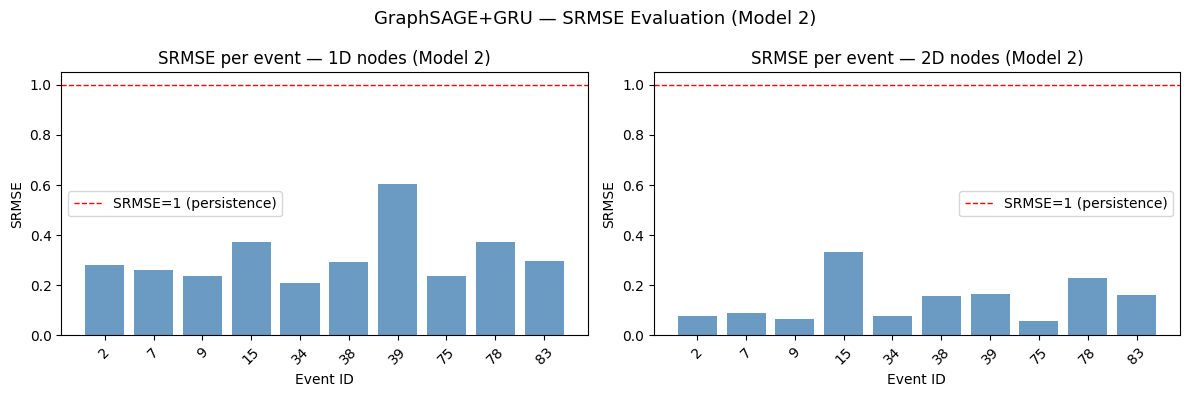


Summary:
  1D: SRMSE = 0.316208  (mean over 10 events)
  2D: SRMSE = 0.141767  (mean over 10 events)
  Overall: SRMSE = 0.228987


In [12]:
# breakdown by node type
import matplotlib.pyplot as plt

std_devs = {
    1: STD_DEV_DICT_FULL[(MODEL_ID, 1)],
    2: STD_DEV_DICT_FULL[(MODEL_ID, 2)],
}

key_cols = ['model_id', 'event_id', 'node_type', 'node_id']
sol_m = solution[solution['model_id'] == MODEL_ID].sort_values(key_cols).reset_index(drop=True)
sub_m = submission[submission['model_id'] == MODEL_ID].sort_values(key_cols).reset_index(drop=True)

unique_events = sorted(sol_m['event_id'].unique())
results = []

for eid in unique_events:
    emask = sol_m['event_id'] == eid
    sol_ev = sol_m[emask]; sub_ev = sub_m[emask]

    for nt, nt_label in [(1, '1D'), (2, '2D')]:
        nmask = sol_ev['node_type'] == nt
        sol_nt = sol_ev[nmask]; sub_nt = sub_ev[nmask]
        if len(sol_nt) == 0: continue

        node_srmses = []
        for nid in sol_nt['node_id'].unique():
            nmask2 = sol_nt['node_id'] == nid
            yt = sol_nt[nmask2]['water_level'].values
            yp = sub_nt[nmask2]['water_level'].values
            if len(yt) > 1:
                v = standardized_rmse(yt, yp, std_devs[nt])
                if not np.isnan(v): node_srmses.append(v)

        if node_srmses:
            results.append({
                'event_id':  eid,
                'node_type': nt_label,
                'srmse':     np.mean(node_srmses),
                'n_nodes':   len(node_srmses)
            })

df_res = pd.DataFrame(results)
print(df_res.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, nt_label in zip(axes, ['1D', '2D']):
    sub_df = df_res[df_res['node_type'] == nt_label]
    if len(sub_df) == 0: continue
    ax.bar(sub_df['event_id'].astype(str), sub_df['srmse'], color='steelblue', alpha=0.8)
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1, label='SRMSE=1 (persistence)')
    ax.set_title(f'SRMSE per event — {nt_label} nodes (Model {MODEL_ID})')
    ax.set_xlabel('Event ID')
    ax.set_ylabel('SRMSE')
    ax.legend()
    ax.tick_params(axis='x', rotation=45)
plt.suptitle(f'GraphSAGE+GRU — SRMSE Evaluation (Model {MODEL_ID})', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nSummary:')
for nt_label in ['1D', '2D']:
    sub_df = df_res[df_res['node_type'] == nt_label]
    if len(sub_df) > 0:
        print(f'  {nt_label}: SRMSE = {sub_df["srmse"].mean():.6f}  (mean over {len(sub_df)} events)')
print(f'  Overall: SRMSE = {srmse_value:.6f}')

---
## Animation — Water Level Time Series (Real vs. Predicted)

In [ ]:
# animation config & rollout

# adjsut here
ANIM_EVENT_IDX = 0      # index in test_dirs (0 = first test event)
ANIM_N_NODES   = 6      # how many 1D nodes to show at once
ANIM_NODE_SEED = 42     # seed for random node selection (None = first N nodes)
ANIM_FPS       = 10     # frames per second

ev_anim = test_dirs[ANIM_EVENT_IDX]
print(f'Animation event: {ev_anim.name}')

wl1d_pred_a, wl2d_pred_a, wl1d_true_a, wl2d_true_a, n_known_a, _ = rollout_event(
    ema_1d, ema_2d, ev_anim,
    (NF_1D, EI_1D, N_1D), (SF_2D, SDIM_2D, N_2D), EI_2D,
    NS_1D, NS_2D
)

# predicted timsteps only
real_1d = wl1d_true_a[n_known_a:]   # (T_pred, N_1D)
pred_1d = wl1d_pred_a[n_known_a:]   # (T_pred, N_1D)
T_pred, N_nodes = real_1d.shape

# node seelction
if ANIM_NODE_SEED is not None:
    rng_a = np.random.RandomState(ANIM_NODE_SEED)
    anim_nodes = rng_a.choice(N_nodes, size=min(ANIM_N_NODES, N_nodes), replace=False)
else:
    anim_nodes = np.arange(min(ANIM_N_NODES, N_nodes))

print(f'  Predicted timesteps:       {T_pred}')
print(f'  Displayed nodes:           {anim_nodes}')
print(f'  Context timesteps (known): {n_known_a}')

In [ ]:
# diagnostics
sigma_1d = STD_DEV_DICT_FULL[(MODEL_ID, 1)]

print(f'σ_global (1D, from Kaggle) = {sigma_1d:.4f}')
print(f'Overall SRMSE              = {srmse_value:.6f}')
print(f'→ Expected abs. RMSE       = {srmse_value * sigma_1d:.4f}  (= SRMSE × σ)')
print()
print(f'{"Node":>8}  {"Y-range":>12}  {"abs.RMSE":>10}  {"SRMSE_k":>10}  {"RMSE/Y-range":>16}')
print('-' * 65)

node_rmses = {}
for node_idx in anim_nodes:
    yt = real_1d[:, node_idx]
    yp = pred_1d[:, node_idx]
    abs_rmse   = float(np.sqrt(np.mean((yt - yp) ** 2)))
    srmse_node = abs_rmse / sigma_1d
    y_range    = yt.max() - yt.min()
    pct_range  = (abs_rmse / y_range * 100) if y_range > 1e-6 else float('nan')
    node_rmses[node_idx] = abs_rmse
    print(f'{node_idx:>8}  {y_range:>12.4f}  {abs_rmse:>10.4f}  {srmse_node:>10.6f}  {pct_range:>14.1f}%')

print()
print('Column explanations:')
print('  Y-range      : max(real) - min(real) for this node → axis scale')
print('  abs.RMSE     : actual error in data units')
print('  SRMSE_k      : this node\'s contribution to SRMSE (= abs.RMSE / σ_global)')
print('  RMSE/Y-range : how large the error is relative to the visible axis scale')
print()
print('→ If RMSE/Y-range is e.g. 20%, the error looks much larger in the animation')
print('  than SRMSE suggests — because the Y-axis shows only the actual variation')
print('  range of the data, not σ_global.')
print()

# overall picture
all_yt = real_1d.flatten()
all_yp = pred_1d.flatten()
total_abs_rmse = float(np.sqrt(np.mean((all_yt - all_yp) ** 2)))
print(f'Absolute RMSE over ALL {N_1D} nodes for this event: {total_abs_rmse:.4f}')
print(f'→ As SRMSE: {total_abs_rmse / sigma_1d:.6f}  (vs. reported SRMSE={srmse_value:.6f})')

In [ ]:
# animation: real water level (1D nodes)
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import matplotlib.pyplot as plt

n_cols = 3
n_rows = (len(anim_nodes) + n_cols - 1) // n_cols
fig_r, axes_r = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes_r = np.array(axes_r).flatten()

y_lims = []
for node_idx in anim_nodes:
    lo = min(real_1d[:, node_idx].min(), pred_1d[:, node_idx].min())
    hi = max(real_1d[:, node_idx].max(), pred_1d[:, node_idx].max())
    pad = max((hi - lo) * 0.1, 0.01)
    y_lims.append((lo - pad, hi + pad))

lines_r, cursors_r = [], []
for ax_i, (node_idx, (ylo, yhi)) in enumerate(zip(anim_nodes, y_lims)):
    ax = axes_r[ax_i]
    line, = ax.plot([], [], color='steelblue', linewidth=1.5)
    cursor = ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_xlim(0, T_pred - 1)
    ax.set_ylim(ylo, yhi)
    rmse_n = node_rmses.get(node_idx, float('nan'))
    y_rng  = real_1d[:, node_idx].max() - real_1d[:, node_idx].min()
    ax.set_title(
        f'Node {node_idx}  |  Y-range: {y_rng:.3f}  |  RMSE: {rmse_n:.4f}',
        fontsize=8
    )
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Water level')
    ax.grid(alpha=0.3)
    lines_r.append(line)
    cursors_r.append(cursor)

for ax in axes_r[len(anim_nodes):]:
    ax.set_visible(False)

fig_r.suptitle(
    f'Real water level — {ev_anim.name}  |  σ_global={sigma_1d:.2f}',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
xs = np.arange(T_pred)

def init_r():
    for line in lines_r: line.set_data([], [])
    return lines_r + cursors_r

def update_r(frame):
    for line, cursor, node_idx in zip(lines_r, cursors_r, anim_nodes):
        line.set_data(xs[:frame + 1], real_1d[:frame + 1, node_idx])
        cursor.set_xdata([frame])
    return lines_r + cursors_r

anim_r = FuncAnimation(fig_r, update_r, frames=T_pred,
                        init_func=init_r, interval=1000 // ANIM_FPS, blit=True)
plt.close(fig_r)
HTML(anim_r.to_jshtml())

In [ ]:
# animation: prediction vs real (1D nodes)
fig_p, axes_p = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes_p = np.array(axes_p).flatten()

lines_pred2, cursors_p = [], []
for ax_i, (node_idx, (ylo, yhi)) in enumerate(zip(anim_nodes, y_lims)):
    ax = axes_p[ax_i]
    ax.plot(xs, real_1d[:, node_idx], color='steelblue', linewidth=1.2,
            alpha=0.35, label='Real')
    lp, = ax.plot([], [], color='tomato', linewidth=1.5, label='Prediction')
    cursor = ax.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.set_xlim(0, T_pred - 1)
    ax.set_ylim(ylo, yhi)
    rmse_n = node_rmses.get(node_idx, float('nan'))
    y_rng  = real_1d[:, node_idx].max() - real_1d[:, node_idx].min()
    pct    = (rmse_n / y_rng * 100) if y_rng > 1e-6 else float('nan')
    ax.set_title(
        f'Node {node_idx}  |  RMSE={rmse_n:.4f}  ({pct:.1f}% of Y-range)',
        fontsize=8
    )
    ax.set_xlabel('Timestep')
    ax.set_ylabel('Water level')
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(alpha=0.3)
    lines_pred2.append(lp)
    cursors_p.append(cursor)

for ax in axes_p[len(anim_nodes):]:
    ax.set_visible(False)

fig_p.suptitle(
    f'Prediction vs. Real — {ev_anim.name}\n'
    f'σ_global={sigma_1d:.2f}  |  overall SRMSE={srmse_value:.4f}  '
    f'|  expected abs. RMSE={srmse_value*sigma_1d:.4f}',
    fontsize=10, fontweight='bold'
)
plt.tight_layout()

def init_p():
    for lp in lines_pred2: lp.set_data([], [])
    return lines_pred2 + cursors_p

def update_p(frame):
    for lp, cursor, node_idx in zip(lines_pred2, cursors_p, anim_nodes):
        lp.set_data(xs[:frame + 1], pred_1d[:frame + 1, node_idx])
        cursor.set_xdata([frame])
    return lines_pred2 + cursors_p

anim_p = FuncAnimation(fig_p, update_p, frames=T_pred,
                        init_func=init_p, interval=1000 // ANIM_FPS, blit=True)
plt.close(fig_p)
HTML(anim_p.to_jshtml())